In [1]:
import numpy as np
import pandas as pd
from skimage import io, measure, color
from skimage.feature import graycomatrix, graycoprops
from skimage.segmentation import find_boundaries
import matplotlib.pyplot as plt



In [3]:
# --- Load Data ---
import os
im_path = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data"
file_name= os.listdir(im_path)
print(file_name)  



['C1-C30000.png', 'C1-C30000_seg.npy', 'C1-C30001.png', 'C1-C30001_seg.npy', 'C1-C30002.png', 'C1-C30002_seg.npy', 'C1-C30003.png', 'C1-C30003_seg.npy', 'C1-C30004.png', 'C1-C30004_seg.npy', 'C1-C30005.png', 'C1-C30005_seg.npy', 'C1-C40000.png', 'C1-C40000_seg.npy', 'C1-C40001.png', 'C1-C40001_seg.npy', 'C1-C40002.png', 'C1-C40002_seg.npy', 'C1-C40003.png', 'C1-C40003_seg.npy', 'C1-C50000.png', 'C1-C50000_seg.npy', 'C1-C50001.png', 'C1-C50001_seg.npy', 'C1-C50002.png', 'C1-C50002_seg.npy', 'C1-C50003.png', 'C1-C50003_seg.npy', 'C1-D10000.png', 'C1-D10000_seg.npy', 'C1-D10001.png', 'C1-D10001_seg.npy', 'C1-D10002.png', 'C1-D10002_seg.npy', 'C1-D10003.png', 'C1-D10003_seg.npy', 'C2-C30000.png', 'C2-C30000_seg.npy', 'C2-C30001.png', 'C2-C30001_seg.npy', 'C2-C30002.png', 'C2-C30002_seg.npy', 'C2-C30003.png', 'C2-C30003_seg.npy', 'C2-C30004.png', 'C2-C30004_seg.npy', 'C2-C30005.png', 'C2-C30005_seg.npy', 'C2-C40000.png', 'C2-C40000_seg.npy', 'C2-C40001.png', 'C2-C40001_seg.npy', 'C2-C40002.

In [6]:

mask_path = os.path.join(im_path, 'C1-C30000_seg.npy')
image_path = os.path.join(im_path, 'C1-C30000.png')

# Load the image (convert to grayscale if it's RGB)
image = io.imread(image_path)
if image.ndim == 3:
    image = color.rgb2gray(image)
# Ensure image is in a standard format (e.g., 8-bit or 16-bit unsigned integer)
image = (image / np.max(image) * 255).astype(np.uint8)


seg_data = np.load(mask_path, allow_pickle=True).item()
# The labeled mask where each nucleus has a unique integer ID
labeled_mask = seg_data['masks'] 

print(f"Loaded image of shape: {image.shape}")
print(f"Loaded labeled mask of shape: {labeled_mask.shape}")

Loaded image of shape: (1024, 1024)
Loaded labeled mask of shape: (1024, 1024)


# visualise

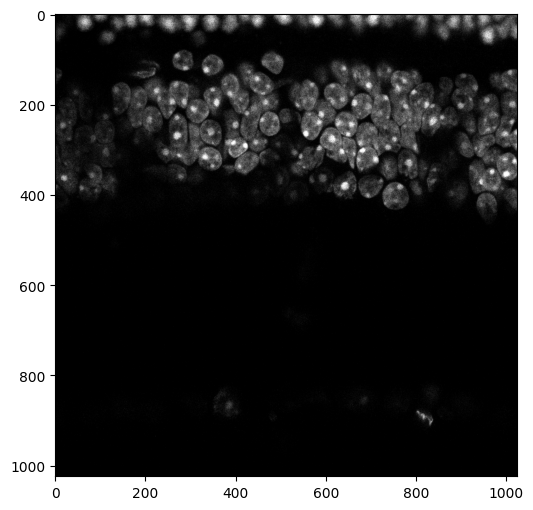

In [7]:
plt.figure(figsize=(12, 6))
plt.imshow(image, cmap='gray')

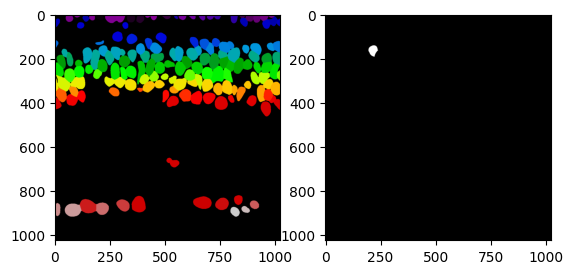

In [19]:
labeled_mask.shape
plt.subplot(1, 2, 1)
plt.imshow(labeled_mask, cmap='nipy_spectral')

cell1_mask = (labeled_mask == 50)
plt.subplot(1, 2, 2)
plt.imshow(cell1_mask, cmap='gray')

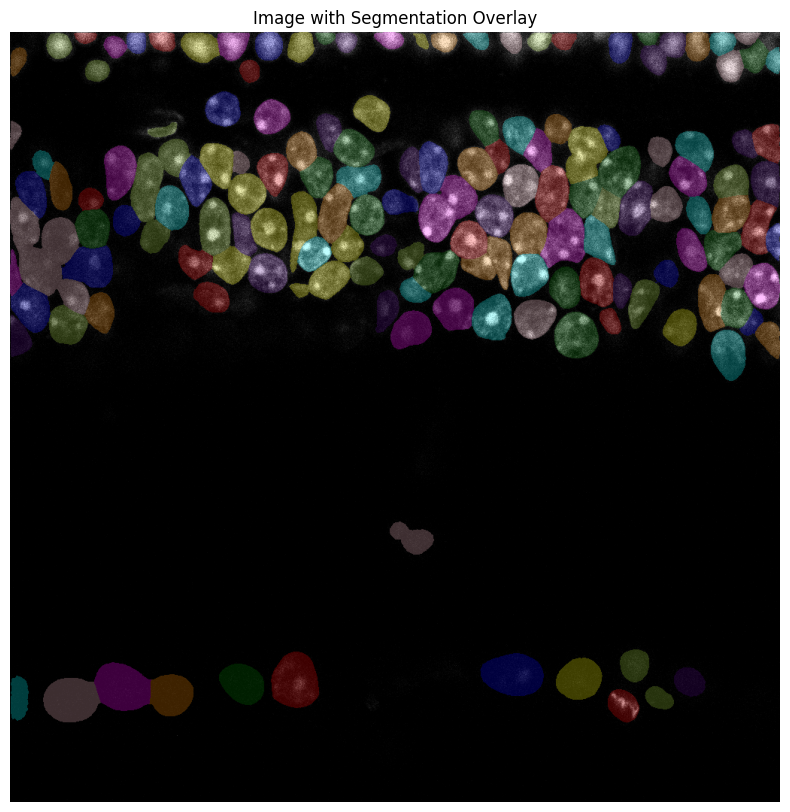

In [9]:
# --- Create and Display Overlay ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image, cmap='gray')

# Create a colored overlay for the masks
# `label2rgb` creates an RGB image where each label is a different color
# `bg_label=0` makes the background transparent
colored_overlay = color.label2rgb(labeled_mask, image=image, bg_label=0, alpha=0.24, image_alpha=1)
ax.imshow(colored_overlay)

ax.set_title("Image with Segmentation Overlay")
ax.axis('off')
plt.show()

# define feature extraction funcions

In [10]:
# --- Define Custom Feature Functions ---
def calculate_circularity(region):
    """Calculates circularity. Handles perimeter=0 case."""
    if region.perimeter == 0:
        return 0
    return (4 * np.pi * region.area) / (region.perimeter ** 2)



In [25]:
def get_glcm_features(region):
    """
    Calculates GLCM texture features for a specific region.
    Uses region.intensity_image where background is 0.
    """
    # region.intensity_image is the intensity image of the region within its bounding box.
    patch = region.intensity_image
    
    # Ensure the patch is not empty
    if patch.size == 0:
        return {'glcm_contrast': 0, 'glcm_homogeneity': 0, 'glcm_energy': 0, 'glcm_correlation': 0}
        
    # Calculate GLCM on the patch. Set normed=False to get counts.
    # We will normalize manually after removing the background.
    glcm = graycomatrix(patch, distances=[1], angles=[0], levels=256, symmetric=True, normed=False)
    
    # Remove the first row and column of the GLCM to ignore co-occurrences with the background (0-intensity pixels)
    glcm[0, :, :, :] = 0
    glcm[:, 0, :, :] = 0
    
    # Manually normalize the GLCM
    total = np.sum(glcm)
    if total == 0:
        # If the sum is 0, it means the region was uniform or empty after filtering.
        # All texture properties will be 0 in this case.
        return {'glcm_contrast': 0, 'glcm_homogeneity': 0, 'glcm_energy': 0, 'glcm_correlation': 0}
        
    glcm_norm = glcm / total
    
    # Calculate properties from the correctly normalized GLCM
    contrast = graycoprops(glcm_norm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm_norm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm_norm, 'energy')[0, 0]
    correlation = graycoprops(glcm_norm, 'correlation')[0, 0]
    
    return {
        'glcm_contrast': contrast, 
        'glcm_homogeneity': homogeneity, 
        'glcm_energy': energy, 
        'glcm_correlation': correlation
    }


In [ ]:

# --- Specify Features to Extract ---
# Features directly available in regionprops
properties_basic = [
    'label', 'area', 'perimeter', 'solidity', 'extent',
    'mean_intensity', 'max_intensity', 'min_intensity',
    'eccentricity', 'major_axis_length', 'minor_axis_length', 'orientation'
]
# Use regionprops to get region objects
props = measure.regionprops(labeled_mask, intensity_image=image)


In [27]:

# --- Manually build the final data dictionary (Corrected Loop) ---
all_features = []
for region in props:
    # Basic features from the predefined list
    features = {prop: getattr(region, prop) for prop in properties_basic}
    
    # Custom features
    features['circularity'] = calculate_circularity(region)
    # The standard deviation of the intensity of pixels in the region
    features['intensity_std'] = np.std(region.intensity_image[region.image]) # Use region.image as a mask to get only foreground pixels

    # Update dictionary with GLCM features
    glcm_feats = get_glcm_features(region)
    features.update(glcm_feats)
    
    all_features.append(features)

# Convert to a pandas DataFrame
df = pd.DataFrame(all_features)

# --- Add Unique Identifiers ---
# Uniquely identify each cell using the filename and its label
image_basename = image_path.split('/')[-1].replace('.jpg', '')
df['unique_id'] = f"{image_basename}_cell_" + df['label'].astype(str)

# Set the unique ID as the index for easy lookup
df.set_index('unique_id', inplace=True)

# Display the first few rows of the final DataFrame
print("Successfully extracted features for", len(df), "cells.")
print(df.head())


Successfully extracted features for 161 cells.
                                                    label    area   perimeter  \
unique_id                                                                       
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Visi...      1   762.0  105.941125   
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Visi...      2  1191.0  126.083261   
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Visi...      3  1177.0  128.325902   
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Visi...      4   697.0  103.840620   
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Visi...      5   395.0   80.526912   

                                                    solidity    extent  \
unique_id                                                                
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Visi...  0.963338  0.814103   
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Visi...  0.981054  0.847084   
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Visi...  0.974338  0.797425   
C:\Users\shiva\

In [32]:
# Save the DataFrame for later use
df.head()

df.to_csv(f'C1-C30000_features.csv', index = False)